## Average bond lifetime + bonding rate from averaging lifetime

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

f = "/mnt/hdd1/patchy_polymers_files/0.7prodpatch_chainlength_31_patchspacing_3_N_beads_24800_gaussA_140_r0_0.25_gaussB_10_seed_12345.bin.txt"

N_patches = 8800
frame = 11

with open(f, "r") as file:
    for i in range((frame - 1) * (9 + N_patches) + 1):
        line = file.readline()
    # for i in range(9):
    print("Timestep:", file.readline())

df = pd.read_csv(f, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)
print(df[df["patch_coord"] == 2])
print(df[df["patch_cluster"] == 8575])

Timestep: 100

Empty DataFrame
Columns: [id, mol, x, y, z, patch_coord, patch_cluster]
Index: []
Empty DataFrame
Columns: [id, mol, x, y, z, patch_coord, patch_cluster]
Index: []


4429
4429
0
4371


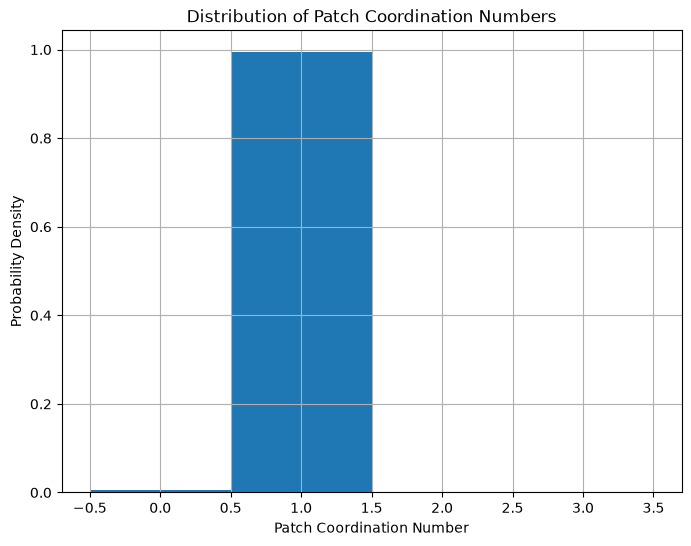

In [26]:
patch_cluster_list = np.unique(df["patch_cluster"].values)
print(len(patch_cluster_list))
cluster_size_list = np.zeros(len(patch_cluster_list))
print(len(cluster_size_list))


for i, patch_cluster in enumerate(patch_cluster_list):
    this_patch = df[df["patch_cluster"] == patch_cluster]
    # print("Patch id:", patch_cluster)
    # print(this_patch)
    cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values)
    # print(f"Cluster {patch_cluster} has size {cluster_size_list[i]}")


# percentage of bonds with 3 patches
num_3_patch_bonds = np.sum(cluster_size_list == 2)
print(num_3_patch_bonds)
total_bonds = np.sum(cluster_size_list == 2) + np.sum(cluster_size_list == 1) # only consider bonds with at least 1 patch
print(total_bonds)
# percentage_3_patch_bonds = (num_3_patch_bonds / total_bonds) * 100
# print(f"Percentage of bonds with 3 patches: {percentage_3_patch_bonds:.2f}%")

# histogram of patch_coord
plt.figure(figsize=(8, 6))
plt.hist(df["patch_coord"], bins=np.arange(-0.5, 4.5, 1), density=True)
plt.title("Distribution of Patch Coordination Numbers")
plt.xlabel("Patch Coordination Number")
plt.ylabel("Probability Density")
plt.grid()
plt.show()  

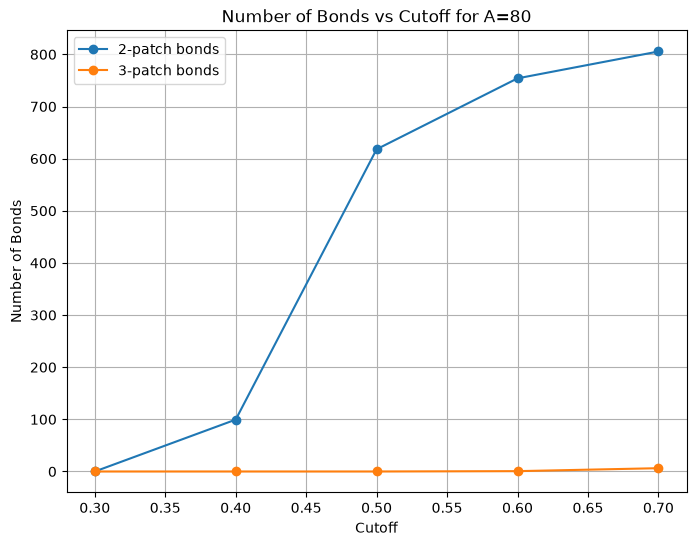

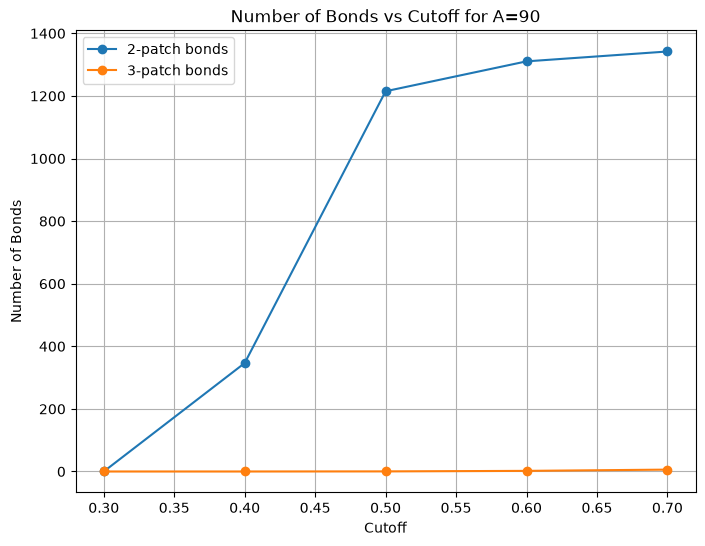

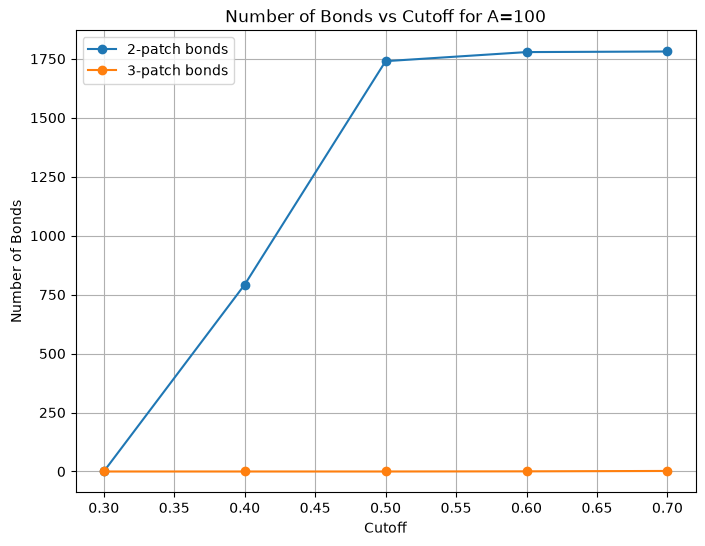

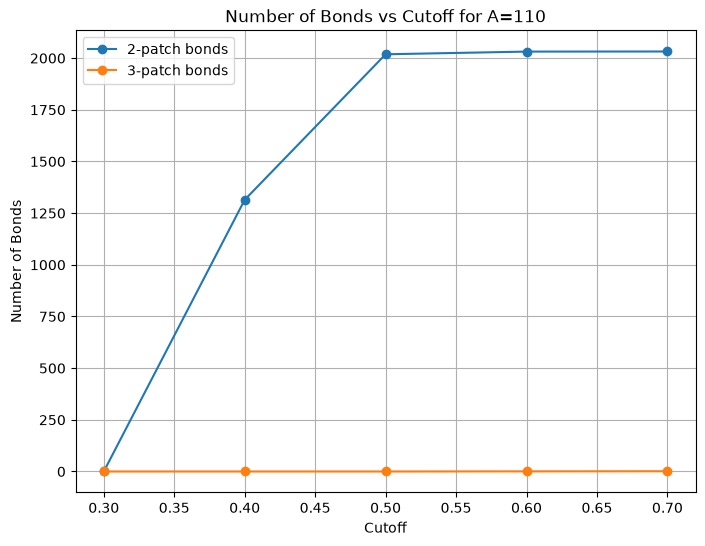

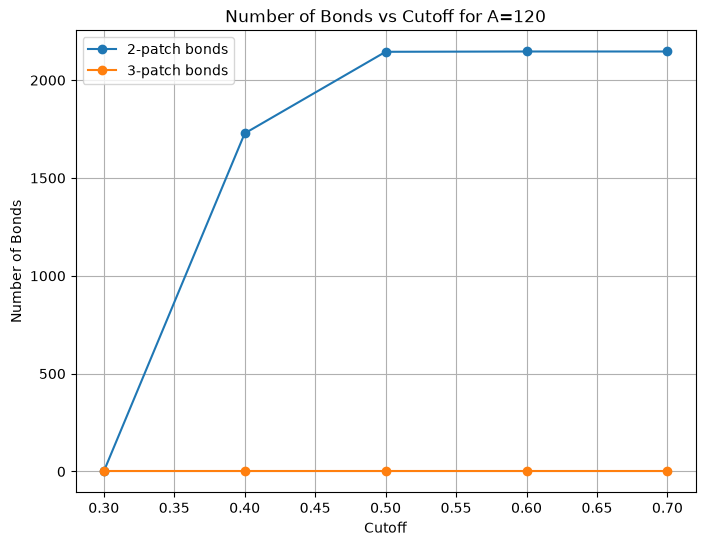

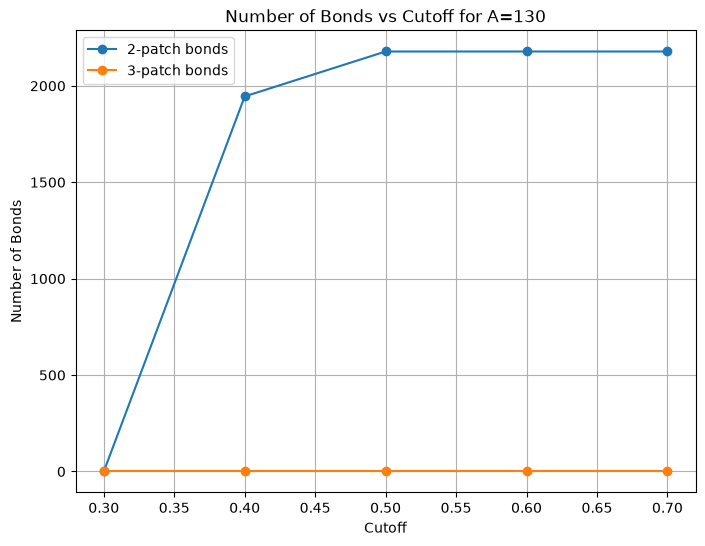

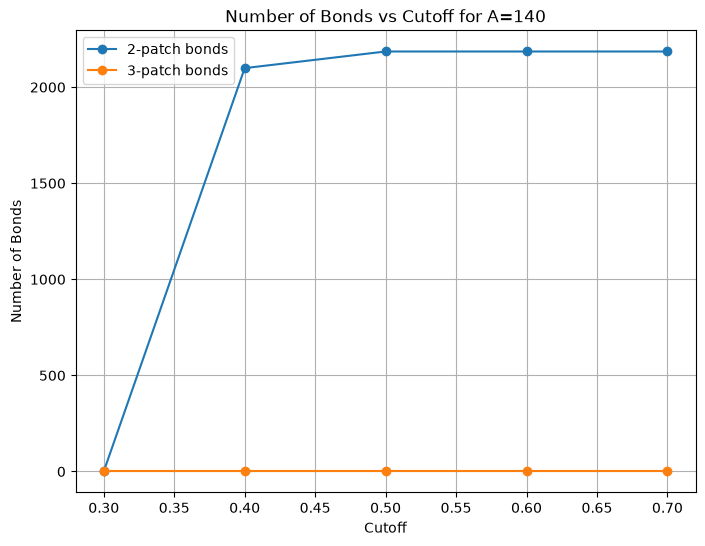

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


for A in [60, 70, 80, 90, 100, 110, 120, 130, 140]:
    two_patch_bond_list = []
    three_patch_bond_list = []
    for cutoff in [0.3, 0.4, 0.5, 0.6, 0.7]:
        filename = f"/mnt/hdd1/patchy_polymers_files/{cutoff}prodpatch_chainlength_31_patchspacing_3_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
        N_patches = 8800
        frame = 11

        # with open(filename, "r") as file:
        #     for i in range((frame - 1) * (9 + N_patches) + 1):
        #         line = file.readline()
        #     print("Timestep:", file.readline())

        df = pd.read_csv(filename, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
        df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)

        patch_cluster_list = np.unique(df["patch_cluster"].values)
        cluster_size_list = np.zeros(len(patch_cluster_list))

        for i, patch_cluster in enumerate(patch_cluster_list):
            this_patch = df[df["patch_cluster"] == patch_cluster]
            cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values) + 1

        two_patch_bond_list.append(np.sum(cluster_size_list == 2)/2)
        three_patch_bond_list.append(np.sum(cluster_size_list == 3)/3)
    
    figure = plt.figure(figsize=(8, 6))
    plt.plot([0.3, 0.4, 0.5, 0.6, 0.7], two_patch_bond_list, marker='o', label="2-patch bonds")
    plt.plot([0.3, 0.4, 0.5, 0.6, 0.7], three_patch_bond_list, marker='x', label="3-patch bonds")
    plt.title(f"Number of Bonds vs Cutoff for A={A}")
    plt.xlabel("Cutoff")
    plt.ylabel("Number of Bonds")
    plt.grid()
    plt.legend()
    plt.show()

## Lifetime algorithm with different $r_{\text{on}}, r_{\text{off}}$

With different radii for forming/breaking a bond, we should avoid jitter close to one cutoff that result in tiny lifetimes. This does require generating and reading two clustering dumps, but we can dump both in one file so we at least won't have too many files.


In [39]:
As = [130]
spacing = 3

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lifetime object:
#   - bonded_pair: (id1, id2)
#   - start_time: timestep when bond is formed
#   - end_time: timestep when bond breaks
#   - lifetime: end_time - start_time

# Read frame
# Filter only consider bonds with at least 1 patch
# sort by patch_cluster (get bonded pairs)
# Create broken flag list for all current bonded pairs
# if already existing in bonded pairs, set flag to false
# if not existing, add to bonded pairs and start counting lifetime until it breaks (patch_coord goes to 0)
# all pairs that have broken flag true, set end_time to current timestep, calculate lifetime, and remove from bonded pairs
"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_buffered_lifetimes(filename_on, filename_off, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off:
            time = 0
            while True:
                # stop reading BOTH if either file is done
                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_on.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                    clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                    for i in range(N_patches):
                        clusters[i] = np.array(f_on.readline().strip().split(), dtype=float)
                    # filter only consider bonds with at least 1 patch
                    clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                    # sort by patch_cluster (get bonded pairs) 
                    clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                    for i in range(len(clusters)-1):
                        id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                        if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                            ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                            current_bonds.add(ids) # add to current bonds set
                    
                    for ids in current_bonds:
                        if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                            bonded_pairs[ids] = time
                    
                    ### broken bonds handled by f_off
                    # broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    # for ids in broken_bonds:
                    #     start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                    #     lifetime = time - start_time
                    #     if (lifetime > timestep):
                    #         bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
                    # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                    # print(bond_lifetimes)

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_off.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                    clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                    for i in range(N_patches):
                        clusters[i] = np.array(f_off.readline().strip().split(), dtype=float)
                    # filter only consider bonds with at least 1 patch
                    clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                    # sort by patch_cluster (get bonded pairs) 
                    clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                    for i in range(len(clusters)-1):
                        id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                        if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                            ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                            current_bonds.add(ids) # add to current bonds set
                    
                    ### creating bonds handled by f_on
                    # for ids in current_bonds:
                    #     if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                    #         bonded_pairs[ids] = time
                    
                    broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    for ids in broken_bonds:
                        start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                        lifetime = time - start_time
                        if (lifetime > timestep):
                            bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
                    # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                    # print(bond_lifetimes)
    return bond_lifetimes



In [41]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

def process_and_save_lifetimes(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    lifetimes = process_buffered_lifetimes(filename_on, filename_off)
    lifetimes_df = pd.DataFrame(lifetimes, columns=["id1", "id2", "start_time", "end_time", "lifetime"])
    lifetimes_df.to_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)} in {time() - start:.2f} seconds")

# only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
# finish = Parallel(n_jobs=6)(delayed(process_and_save_lifetimes)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on < cutoff_off for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.4, total lifetimes recorded: 8985750


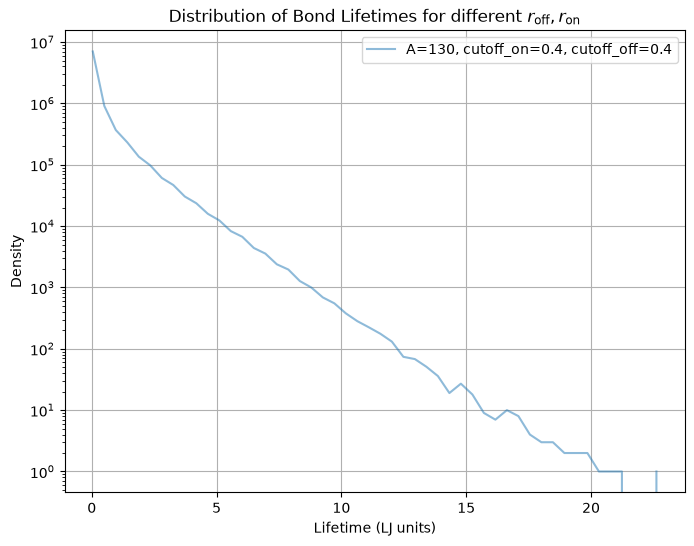

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 12578
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 13947


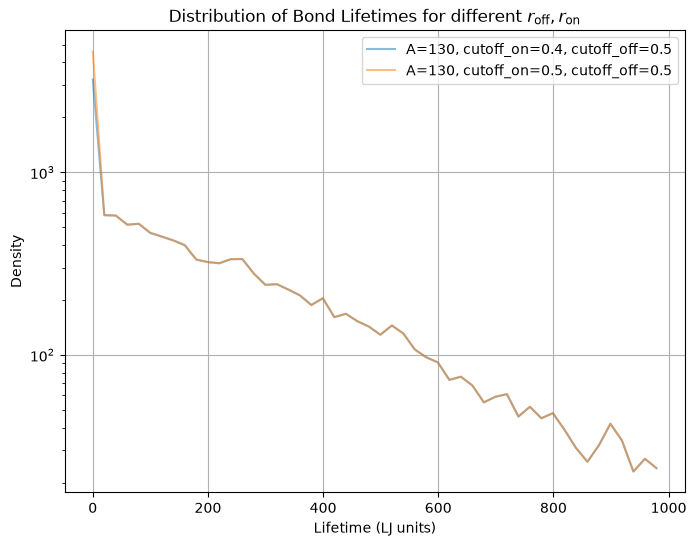

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 1477
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 2745
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 5189


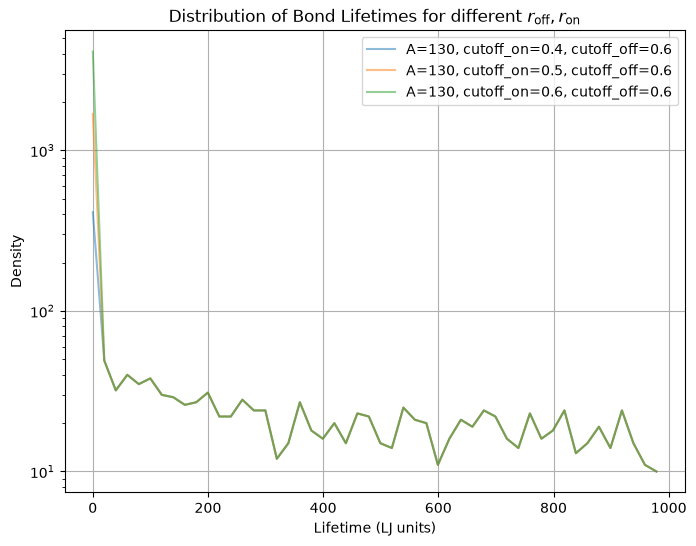

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 3987
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 5405
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 7519
Processed lifetimes for A=130, cutoff_on=0.7, cutoff_off=0.7, total lifetimes recorded: 15383


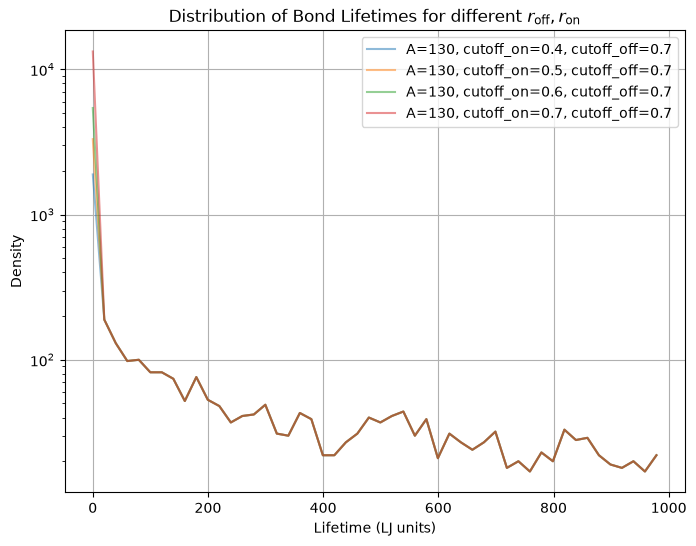

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()

for cutoff_off in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for cutoff_on in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on <= cutoff_off:
            for A in As:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25_spacing_{spacing}.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
        # if cutoff_on == cutoff_off:
        #     for A in [140]:
        #         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff_on}_r0_0.25.csv")
        #         lifetimes = np.array(df["lifetime"].values)
        #         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

        #         # values, counts = np.unique(lifetimes, return_counts=True)
        #         hist, bins = np.histogram(lifetimes, bins=50)


        #         plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
        #         print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    # plt.ylim(0, 0.2)
    plt.grid()
    plt.title(r"Distribution of Bond Lifetimes for different $r_{\text{off}}, r_{\text{on}}$")
    plt.legend()
    plt.show()

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 12578
Removing, remaining lifetimes recorded: 9358
Fitted coefficients for A=130, cutoff_on=0.4, cutoff_off=0.5: [3.24079649e+02 3.17546379e-03 3.23340391e+02 3.17546033e-03]
Fitted lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.5: tau_1=314.91, tau_2=314.91
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 13947
Removing, remaining lifetimes recorded: 9360
Fitted coefficients for A=130, cutoff_on=0.5, cutoff_off=0.5: [3.23942441e+02 3.17580916e-03 3.23686909e+02 3.17583370e-03]
Fitted lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.5: tau_1=314.88, tau_2=314.88


/tmp/ipykernel_1411153/177383806.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


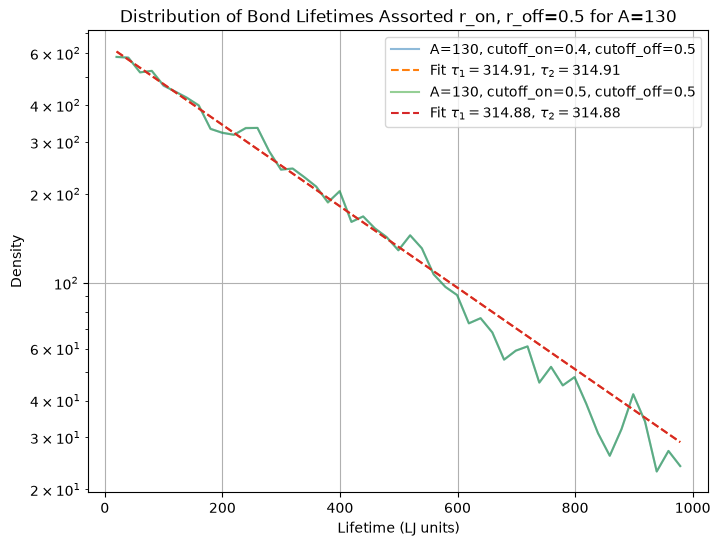

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 1477
Removing, remaining lifetimes recorded: 1065
Fitted coefficients for A=130, cutoff_on=0.4, cutoff_off=0.6: [2.11712736e+01 2.71182654e-04 2.80309905e+01 8.25111201e-03]
Fitted lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.6: tau_1=121.20, tau_2=3687.55
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 2745
Removing, remaining lifetimes recorded: 1065
Fitted coefficients for A=130, cutoff_on=0.5, cutoff_off=0.6: [2.11712736e+01 2.71182654e-04 2.80309905e+01 8.25111201e-03]
Fitted lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.6: tau_1=121.20, tau_2=3687.55
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 5189
Removing, remaining lifetimes recorded: 1065
Fitted coefficients for A=130, cutoff_on=0.6, cutoff_off=0.6: [2.11712736e+01 2.71182654e-04 2.80309905e+01 8.25111201e-03]
Fitted lifetimes for A=130, cutoff_on=0.

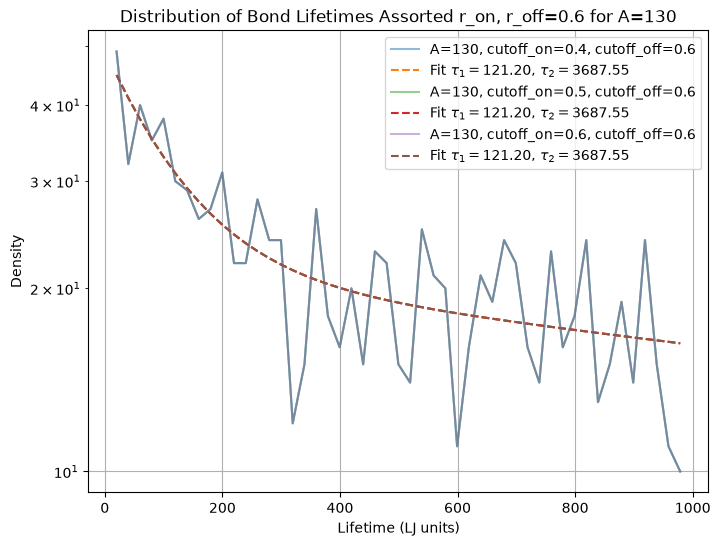

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 3987
Removing, remaining lifetimes recorded: 2097
Fitted coefficients for A=130, cutoff_on=0.4, cutoff_off=0.7: [5.61572870e+01 1.09680780e-03 1.72162174e+02 1.69383292e-02]
Fitted lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.7: tau_1=59.04, tau_2=911.74
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 5405
Removing, remaining lifetimes recorded: 2097
Fitted coefficients for A=130, cutoff_on=0.5, cutoff_off=0.7: [5.61572870e+01 1.09680780e-03 1.72162174e+02 1.69383292e-02]
Fitted lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.7: tau_1=59.04, tau_2=911.74
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 7519
Removing, remaining lifetimes recorded: 2097
Fitted coefficients for A=130, cutoff_on=0.6, cutoff_off=0.7: [5.61572870e+01 1.09680780e-03 1.72162174e+02 1.69383292e-02]
Fitted lifetimes for A=130, cutoff_on=0.6, c

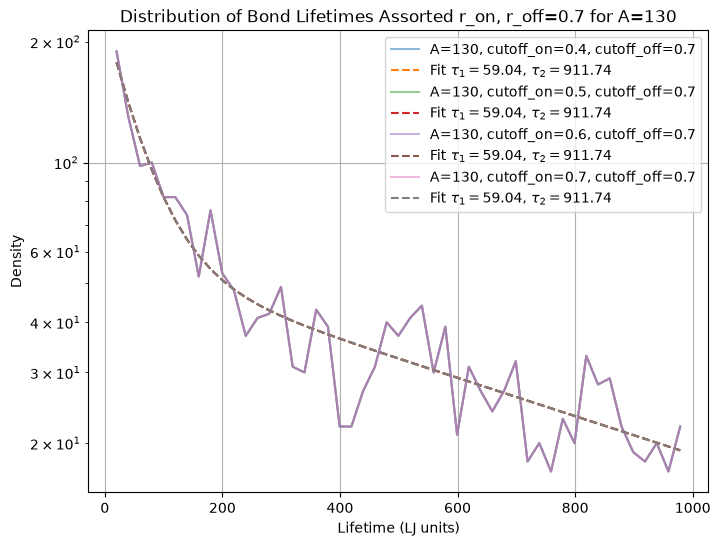

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def biexponential(x, a1, b1, a2, b2):
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)

def single_exponential(x, a, b):
    return a * np.exp(-b * x)




for cutoff_off in [ 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for cutoff_on in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on <= cutoff_off:
            for A in As:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25_spacing_{spacing}.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=10000)
                print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}")

                # coeffs, cov = curve_fit(single_exponential, bins[:-1], hist, p0=[1, 0.01])
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                # plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                # plt.plot(bins[:-1], single_exponential(bins[:-1], *coeffs), '--', label=f"Fit A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            
            # plt.xlabel("Lifetime (LJ units)")
            # plt.ylabel("Density")
            # # plt.yscale("log")
            # # plt.ylim(0, 0.2)
            # plt.grid()
            # plt.title(f"Distribution of Bond Lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            # plt.legend()
            # plt.show()
            
        # if cutoff_on == cutoff_off:
        #     for A in [130]:
        #         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff_on}_r0_0.25.csv")
        #         lifetimes = np.array(df["lifetime"].values)
        #         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

        #         # values, counts = np.unique(lifetimes, return_counts=True)
        #         hist, bins = np.histogram(lifetimes, bins=50)


        #         print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
        #         hist = hist[1:] # remove first bin
        #         bins = bins[1:] # remove first bin
        #         print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

        #         coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=10000)
        #         print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
        #         tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
        #         print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                
        #         plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
        #         plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}")

        #         # coeffs, cov = curve_fit(single_exponential, bins[:-1], hist, p0=[1, 0.01])
        #         # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
        #         # plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
        #         # plt.plot(bins[:-1], single_exponential(bins[:-1], *coeffs), '--', label=f"Fit A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                
        #     # plt.xlabel("Lifetime (LJ units)")
        #     # plt.ylabel("Density")
        #     # # plt.yscale("log")
        #     # # plt.ylim(0, 0.2)
        #     # plt.grid()
        #     # plt.title(f"Distribution of Bond Lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
        #     # plt.legend()
        #     # plt.show()
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    # plt.ylim(0, 0.2)
    plt.grid()
    plt.title(f"Distribution of Bond Lifetimes Assorted r_on, r_off={cutoff_off} for A={A}")
    plt.legend()
    plt.show()

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.4, total lifetimes recorded: 8985750
Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 12578
Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 1477
Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 3987
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 13947
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 2745
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 5405
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 5189
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 7519


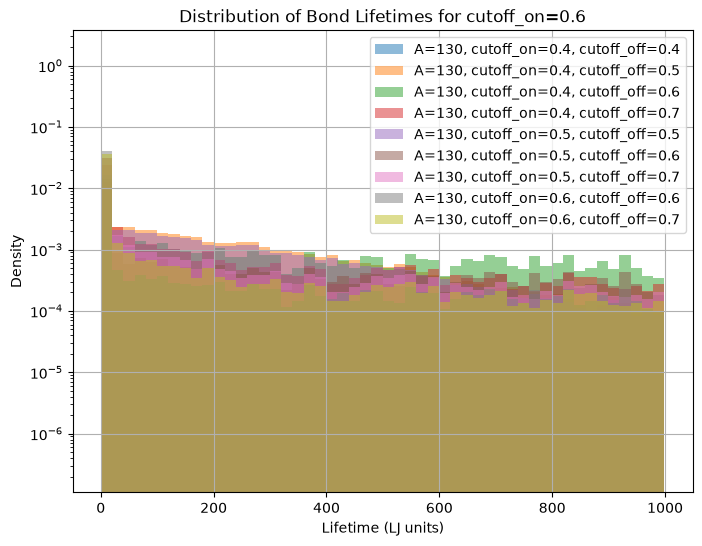

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()
fig = plt.figure(figsize=(8, 6))
for cutoff_on in [0.4, 0.5, 0.6]:
    
    for cutoff_off in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on <= cutoff_off:
            for A in As:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25_spacing_{spacing}.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)


                plt.hist(lifetimes, bins=50, alpha=0.5,density=True, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
plt.xlabel("Lifetime (LJ units)")
plt.ylabel("Density")
plt.yscale("log")
# plt.ylim(0, 0.2)
plt.grid()
plt.title(f"Distribution of Bond Lifetimes for cutoff_on={cutoff_on}")
plt.legend()
plt.show()

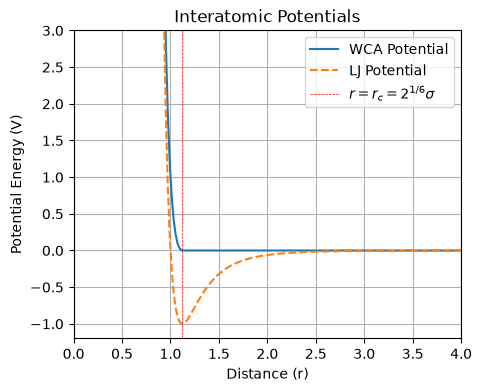

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 4, 200)
def wca(x: np.ndarray) -> np.ndarray:
    """
    Compute the Weeks-Chandler-Andersen (WCA) potential for a given array of distances.

    Parameters:
    x (np.ndarray): An array of distances.

    Returns:
    np.ndarray: An array of WCA potential values corresponding to the input distances.
    """
    # WCA potential parameters
    epsilon = 1.0  # Depth of the potential well
    sigma = 1.0    # Finite distance at which the inter-particle potential is zero

    # Calculate the WCA potential
    wca_potential = np.where(
        x < 2**(1/6) * sigma,
        4 * epsilon * ((sigma / x)**12 - (sigma / x)**6) + epsilon,
        0.0
    )
    
    return wca_potential

def lj(x: np.ndarray) -> np.ndarray:
    """
    Compute the Lennard-Jones (LJ) potential for a given array of distances.

    Parameters:
    x (np.ndarray): An array of distances.

    Returns:
    np.ndarray: An array of LJ potential values corresponding to the input distances.
    """
    # LJ potential parameters
    epsilon = 1.0  # Depth of the potential well
    sigma = 1.0    # Finite distance at which the inter-particle potential is zero

    # Calculate the LJ potential
    lj_potential = 4 * epsilon * ((sigma / x)**12 - (sigma / x)**6)
    
    return lj_potential

y_wca = wca(x)
y_lj = lj(x)

plt.figure(figsize=(5, 4))
plt.plot(x, y_wca, label="WCA Potential")
plt.plot(x, y_lj, label="LJ Potential", linestyle='--')
plt.title("Interatomic Potentials")
plt.xlabel("Distance (r)")
plt.ylabel("Potential Energy (V)")
# plt.axhline(0, color='black', lw=0.5, ls='-')
plt.axvline(2**(1/6), color='red', lw=0.5, ls='--', label=r"$r = r_c=2^{1/6} \sigma$")
plt.legend()
plt.grid()
plt.xlim(0, 4)
plt.ylim(-1.2, 3)
plt.show()

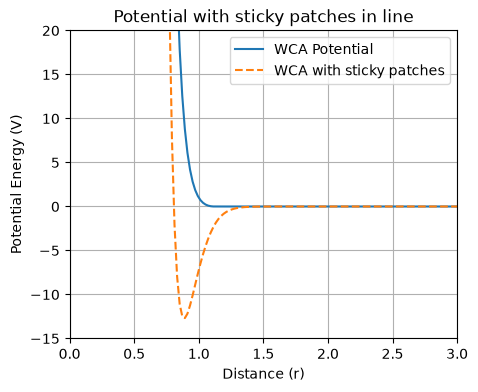

In [18]:
def gauss_WCA(x: np.array) -> np.array:
    """
    Compute the Gaussian-modified Weeks-Chandler-Andersen (WCA) potential for a given array of distances.

    Parameters:
    x (np.ndarray): An array of distances.

    Returns:
    np.ndarray: An array of Gaussian-modified WCA potential values corresponding to the input distances.
    """
    # WCA potential parameters
    epsilon = 1.0  # Depth of the potential well
    sigma = 1.0    # Finite distance at which the inter-particle potential is zero

    # Gaussian parameters
    A = 100.0        # Amplitude of the Gaussian
    r0 = 0.25      # Center of the Gaussian
    B = 10.0       # Width of the Gaussian

    # Calculate the WCA potential
    wca_potential = np.where(
        x < 2**(1/6) * sigma,
        4 * epsilon * ((sigma / x)**12 - (sigma / x)**6) + epsilon,
        0.0
    )

    # Calculate the Gaussian term
    gaussian_term = -A * np.exp(-B * (x - 2*r0)**2)

    # Combine WCA and Gaussian potentials
    gauss_wca_potential = wca_potential + gaussian_term
    
    return gauss_wca_potential

fig = plt.figure(figsize=(5, 4))
x = np.linspace(0.01, 4, 200)
y_gauss_wca = gauss_WCA(x)
y_wca = wca(x)
plt.plot(x, y_wca, label="WCA Potential")
plt.plot(x, y_gauss_wca, linestyle="--", label="WCA with sticky patches")
plt.title("Potential with sticky patches in line")
plt.xlabel("Distance (r)")
plt.ylabel("Potential Energy (V)")
# plt.axvline(2**(1/6), color='red', lw=0.5, ls='--', label=r"$r = r_c=2^{1/6} \sigma$")
plt.legend()
plt.grid()
plt.xlim(0, 3)
plt.ylim(-15, 20)
plt.show()

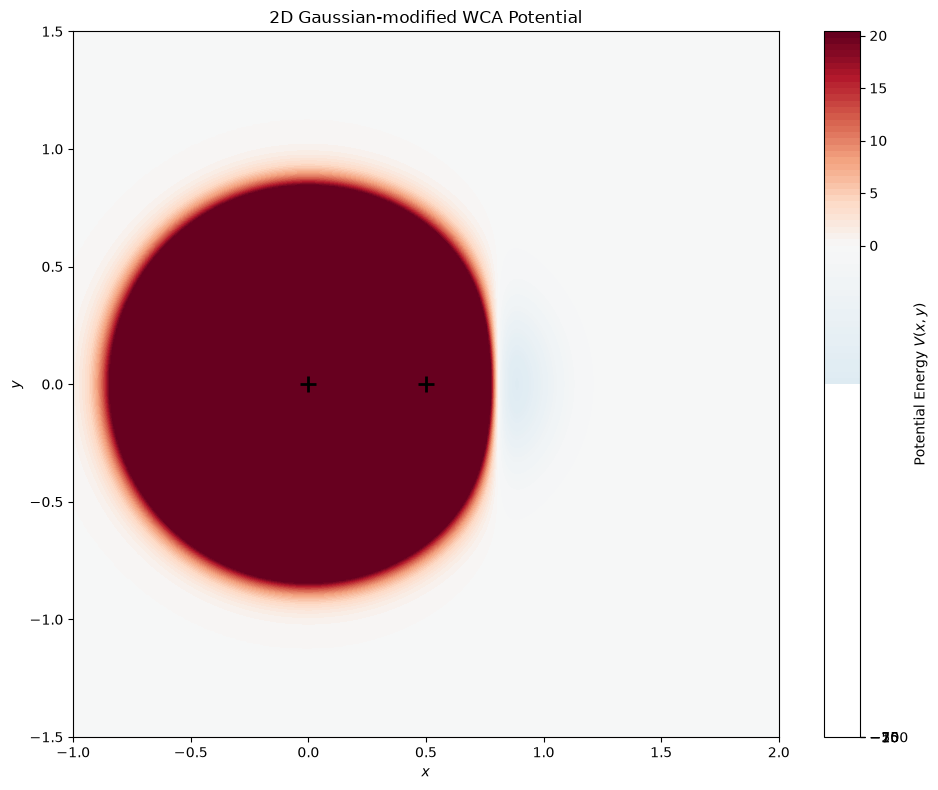

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
A = 100.0
B = 10.0
x_d = 0.25

def gauss_wca_2d(x, y):
    R = np.sqrt(x**2 + y**2)
    r_d = np.sqrt((x - 2*x_d)**2 + y**2)

    # Avoid division by zero at R = 0
    R_safe = np.maximum(R, 1e-10)

    # WCA term
    wca_term = np.where(
        R < 2**(1/6),
        4 * ((1/R_safe)**12 - (1/R_safe)**6) + 1,
        0
    )

    # Gaussian attractive well
    gaussian_term = -A * np.exp(-B * r_d**2)

    return gaussian_term + wca_term


# Create grid
x = np.linspace(-1, 2, 500)
y = np.linspace(-1.5, 1.5, 500)
X, Y = np.meshgrid(x, y)

V = gauss_wca_2d(X, Y)

# Clip the potential for visualization
V_plot = np.clip(V, -A, 20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

levels = np.linspace(-A, 20, 60)

contourf = ax.contourf(
    X, Y, V_plot,
    levels=levels,
    cmap='RdBu_r',
    extend='both'
)

cbar = fig.colorbar(contourf, ax=ax)
cbar.set_label(r'Potential Energy $V(x,y)$')

# Mark the WCA particle center and Gaussian patch center
ax.plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
ax.plot(2*x_d, 0, 'k+', markersize=12, markeredgewidth=2)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_aspect('equal')
ax.set_title(r'2D Gaussian-modified WCA Potential')

plt.tight_layout()
plt.show()